In [1]:
!pip install shap lime xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=2ffff901cd04834debc59b98a4beb91da3988c6bb6dd64abfb6e6943a2ea35c8
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

import shap

from lime.lime_tabular import LimeTabularExplainer

In [4]:
diabetes_train = pd.read_csv("diabetes-train.csv")

diabetes_test = pd.read_csv("diabetes-test.csv")

ckd = pd.read_csv("kidney_disease.csv")

In [5]:
X_train_diab = diabetes_train.drop("Diabetes_binary", axis=1)

y_train_diab = diabetes_train["Diabetes_binary"]

X_test_diab = diabetes_test.drop("Diabetes_binary", axis=1)

y_test_diab = diabetes_test["Diabetes_binary"]

In [6]:
ckd.columns = ckd.columns.str.strip().str.lower()

ckd = ckd.drop('id', axis=1)

ckd = ckd.applymap(
    lambda x: x.strip() if isinstance(x, str) else x
)

/tmp/ipykernel_9759/1955430645.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ckd = ckd.applymap(


In [7]:
ckd = ckd.replace({
    'yes': 1,
    'no': 0,
    'present': 1,
    'notpresent': 0,
    'ckd': 1,
    'ckd\t': 1,
    'notckd': 0,
    'good': 1,
    'poor': 0,
    'normal': 1,
    'abnormal': 0
})

/tmp/ipykernel_9759/596628750.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ckd = ckd.replace({


In [8]:
for col in ckd.columns:
    ckd[col] = pd.to_numeric(
        ckd[col],
        errors='coerce'
    )

In [9]:
imputer = SimpleImputer(strategy='median')

ckd = pd.DataFrame(
    imputer.fit_transform(ckd),
    columns=ckd.columns
)

In [10]:
X_ckd = ckd.drop("classification", axis=1)

y_ckd = ckd["classification"]

In [11]:
X_train_ckd, X_test_ckd, y_train_ckd, y_test_ckd = train_test_split(
    X_ckd,
    y_ckd,
    test_size=0.2,
    random_state=42
)

In [12]:
rf_diab = RandomForestClassifier(random_state=42)

rf_diab.fit(X_train_diab, y_train_diab)

y_pred_diab = rf_diab.predict(X_test_diab)

print("Diabetes Accuracy:")

print(
    accuracy_score(
        y_test_diab,
        y_pred_diab
    )
)

Diabetes Accuracy:
0.7780747398297068


In [13]:
rf_ckd = RandomForestClassifier(random_state=42)

rf_ckd.fit(X_train_ckd, y_train_ckd)

y_pred_ckd = rf_ckd.predict(X_test_ckd)

print("CKD Accuracy:")

print(
    accuracy_score(
        y_test_ckd,
        y_pred_ckd
    )
)

CKD Accuracy:
1.0


In [14]:
xgb_ckd = XGBClassifier()

xgb_ckd.fit(X_train_ckd, y_train_ckd)

y_pred_xgb = xgb_ckd.predict(X_test_ckd)

print("XGBoost Accuracy:")

print(
    accuracy_score(
        y_test_ckd,
        y_pred_xgb
    )
)

XGBoost Accuracy:
0.9875


In [15]:
print(classification_report(
    y_test_ckd,
    y_pred_ckd
))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        28
         1.0       1.00      1.00      1.00        52

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



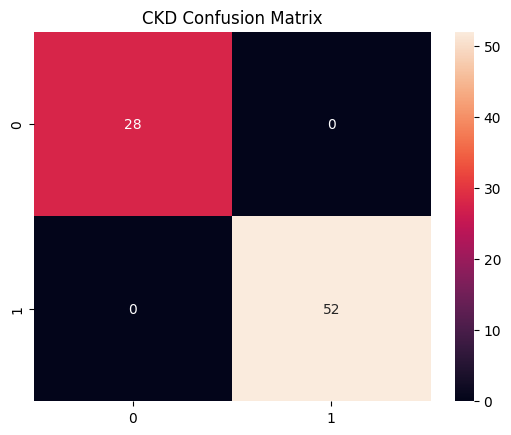

In [16]:
cm = confusion_matrix(
    y_test_ckd,
    y_pred_ckd
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("CKD Confusion Matrix")

plt.savefig(
    "confusion_matrix_rf.png"
)

plt.show()

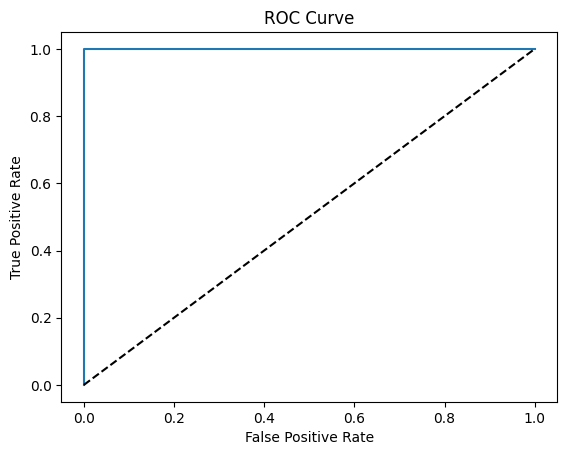

In [17]:
y_prob = rf_ckd.predict_proba(X_test_ckd)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test_ckd,
    y_prob
)

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.savefig("roc_curve_models.png")

plt.show()

In [18]:
explainer = shap.Explainer(
    rf_ckd,
    X_train_ckd
)

shap_values = explainer(X_test_ckd)

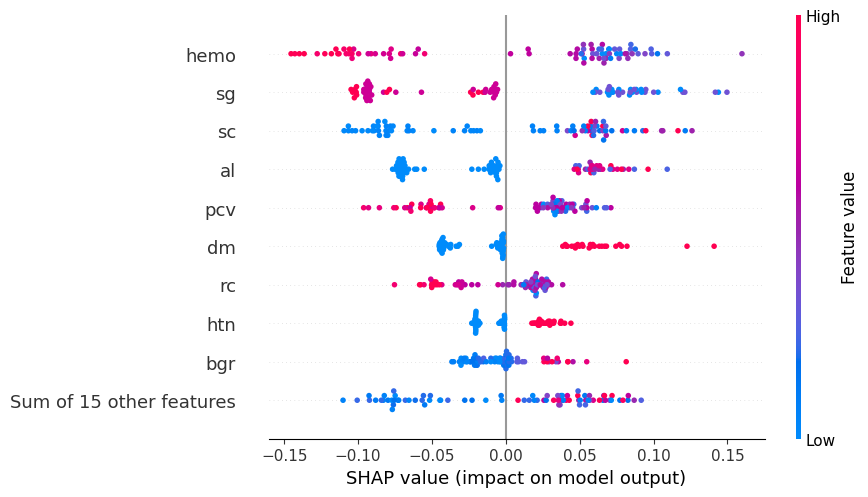

In [23]:
shap.plots.beeswarm(
    shap_values[:, :, 1],
    show=False
)

plt.savefig(
    "shap_summary_ckd.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

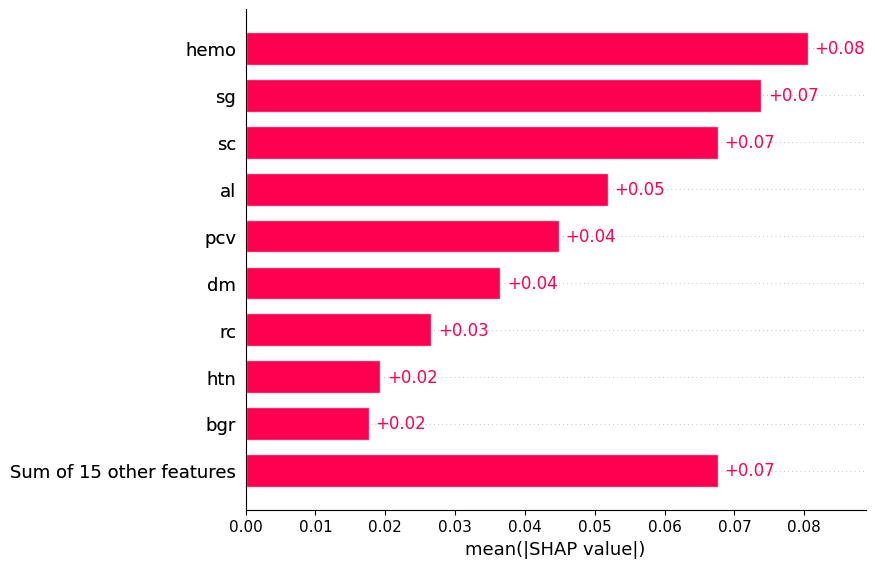

In [20]:
shap.plots.bar(
    shap_values[:, :, 1]
)

In [21]:
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train_ckd),
    feature_names=X_train_ckd.columns,
    class_names=['No CKD', 'CKD'],
    mode='classification'
)

exp = lime_explainer.explain_instance(
    X_test_ckd.iloc[0],
    rf_ckd.predict_proba
)

exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

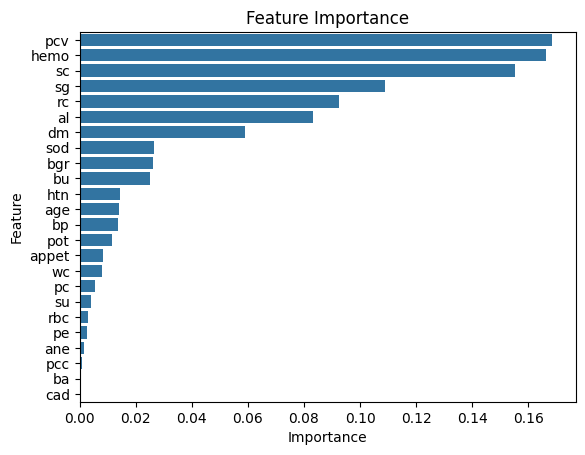

In [22]:
importance = pd.DataFrame({
    'Feature': X_ckd.columns,
    'Importance': rf_ckd.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.savefig(
    "feature_importance.png"
)

plt.show()